In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(genefilter)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

## consolidate all dada2 runs into one

### tracking reads

In [3]:
track1=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_Seqnums_16S.csv")

track2=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_Seqnums_16S.csv")

track3=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_Seqnums_16S.csv")

track4=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_Seqnums_16S.csv")

track5=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_Seqnums_16S.csv")

In [4]:
track <- bind_rows(track1, track2, track3, track4, track5)

### asv_nochim

In [172]:
asv1=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_16S_ASV_nochim.csv")

asv2=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_ASV_nochim.csv")

asv3=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_16S_ASV_nochim.csv")

asv4=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_16S_ASV_nochim.csv")

asv5=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_16S_ASV_nochim.csv")

In [173]:
asv <- bind_rows(asv1, asv2, asv3, asv4, asv5)

### taxa

In [174]:
taxa1=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_16S_taxa.csv", header=TRUE, row.names=1)

taxa2=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_taxa.csv", header=TRUE, row.names=1)

taxa3=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_16S_taxa.csv", header=TRUE, row.names=1)

taxa4=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_16S_taxa.csv", header=TRUE, row.names=1)

taxa5=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_16S_taxa.csv", header=TRUE, row.names=1)

In [175]:
taxa <- bind_rows(taxa1, taxa2, taxa3, taxa4, taxa5)

### cleaning track of samples with less than 10K reads

In [176]:
clean_track <- track[track$nonchim > 10000, ]
setnames(clean_track, c("V1"), c("Tubelabel_species"), skip_absent=TRUE)
head(clean_track)

Tubelabel_species,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024-BEL-CBC-T1-557-SSID,140907,132539,130818,130771,127036,118800
012024-BEL-CBC-T1-563-PSTR,97665,89798,89392,89308,88670,48116
012024-BEL-CBC-T2-601-OFAV,263467,250569,249704,249707,248016,191585
012024-BEL-CBC-T2-605-SSID,605361,574264,571735,571551,564520,517961
012024-BEL-CBC-T3-627-PAST,1656969,1561240,1540358,1539923,1487115,1323604
012024-BEL-CBC-T3-631-MCAV,513353,484960,483847,483931,476841,424109


In [177]:
#check to make sure clean_track matches asv_clean
nrow(track)
nrow(clean_track)
#which samples got removed for having under 10K reads
anti_join(track, clean_track, by = NULL, copy = FALSE)

[1] 484

[1] 478

Joining with `by = join_by(input, filtered, denoisedF, denoisedR, merged,
nonchim)`


V1,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
042024-BEL-CBC-T3-960-OFAV,20490,19399,18468,18916,17869,3853
122022-BEL-CBC-T3-142-MCAV,7052,6583,6291,6279,6067,4868
Negative,1768,1604,1352,1322,971,940
Undetermined,13745,5518,4925,4873,4191,2655
012024-BEL-CBC-T1-561-OANN,5678,3850,3576,3504,2767,765
Negative,27732,20564,19837,20168,10211,6771


### sample metadata


In [178]:
meta=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/meta_PCR.csv", header=TRUE)

In [179]:
colnames(meta)

[1] "X"                            "Tubelabel_species"           
 [3] "Date_Extracted"               "Raw_ng_ul"                   
 [5] "Date_Enriched"                "Microbe_Location"            
 [7] "Month_year"                   "colony"                      
 [9] "CollectionDate"               "Species"                     
[11] "Health_status"                "Sample_physical_location"    
[13] "Extraction_physical_location" "immune_y.n"                  
[15] "Condition"                    "Date_16S"                    
[17] "Date_ITS2"                    "Seq_run"                     
[19] "Transect"

In [180]:
unique(meta$Month_year)

[1]  52022  92023  22024  82024 122023 112023  42024  62019 122022 102019
[11]  62024  12024     NA

In [181]:
#changing format of Month_year to be Jan 2024 using collection date
meta$CollectionDate <- as.factor(meta$CollectionDate)
# Convert to Date format 
meta$DateFormatted <- as.Date(paste0(meta$CollectionDate), format = "%m/%d/%y")
# now will have a new column that has Month Year instead of date_sampled
meta$Month_year <- format(meta$DateFormatted, "%b %Y")
meta$Month_year <- factor(meta$Month_year, levels = unique(meta$Month_year))

#MonthYear in chronological order
head(meta)

X,Tubelabel_species,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,Extraction_physical_location,immune_y.n,Condition,Date_16S,Date_ITS2,Seq_run,Transect,DateFormatted
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<date>
104,052022_BEL_CBC_T1_2_SSID,12_2_2024,7.73,,,May 2022,1_3,5/21/22,SSID,Diseased_Tissue,UML_NARWHAL_R1_B3,"UML_NARWHAL_R2_B14, UML_NARWHAL_R2_B33",y,Diseased,1_22_2025,6_26_2025,1,CBC30N,2022-05-21
232,092023_BEL_CBC_T1_175_PAST,1_15_2025,2.3,,,Sep 2023,1_13,9/25/23,PAST,Healthy,UML_NARWHAL_R1_B10,UML_NARWHAL_R2_B12,y,Healthy,1_22_2025,6_26_2025,1,CBC30N,2023-09-25
59,022024_BEL_CBC_T3_851_PSTR,11_26_2024,64.2,,,Feb 2024,3_70,2/24/24,PSTR,Healthy,UML_NARWHAL_R5_B23,UML_NARWHAL_R2_B13,y,Healthy,1_23_2025,6_26_2025,1,Lagoon,2024-02-24
225,082024_BEL_CBC_T4_1609_OFAV,1_15_2025,61.2,,,Aug 2024,4_78,8/22/24,OFAV,Healthy,UML_NARWHAL_R5_B27,UML_NARWHAL_R2_B15,y,Healthy,1_23_2025,6_26_2025,1,Curlew,2024-08-22
360,122023_BEL_CBC_T3_526_SSID,11_19_2024,16.4,,,Dec 2023,3_5,12/16/23,SSID,Healthy,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B13,y,Healthy,1_23_2025,6_26_2025,1,Lagoon,2023-12-16
300,112023_BEL_CBC_T4_399_MCAV,11_15_2024,13.9,,,Nov 2023,4_76,11/13/23,MCAV,Bleached_Tissue,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B12,y,CLP,1_23_2025,6_26_2025,1,Curlew,2023-11-13


In [182]:
 #cleaning up meta to only be of interest
meta_clean<- meta[, c("Tubelabel_species", "Health_status", "colony", "Date_16S", "Condition", "Species", "Month_year", "Seq_run", "Transect", "DateFormatted")]
head(meta_clean)

Tubelabel_species,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13


### joining clean track and asv

In [183]:
#reconfigure names in asv_all
setDT(asv, keep.rownames = "Tubelabel_species")[]
setnames(asv, c("V1"), c("Tubelabel_species"), skip_absent=TRUE)

V1,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,⋯,ATAAGAGACAGTGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCGAGTAGTCCCCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCCGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,ATAAGAGACAGCGTGTCAGCAGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGTGGGGGGGGGTTTTTTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACAGCAGATGATCTGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TCTTATACACATCTCCGAGCCCACGAGACCGAGACTAATCTGGGGGGGGGGGGTGGGGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

In [184]:
#great now inner join to format asv_all based on clean_track
# Ensure both are data.tables
setDT(asv)
setDT(clean_track)
asv_clean <- merge(asv, clean_track, by = "Tubelabel_species", all = FALSE)

In [185]:
# Replace any '-' with '_' in asv_clean$Tube
asv_clean$Tubelabel_species <- gsub("-", "_", asv_clean$Tubelabel_species)

### now filtering metadt based on track

In [186]:
#exclude samples that are not in asv_clean
metadf <- merge(meta_clean, asv_clean, by = "Tubelabel_species", all = FALSE)
 #cleaning up meta to only be of interest
metadf<- metadf[, c("Tubelabel_species", "Health_status", "colony", "Date_16S", "Condition", "Species", "Month_year", "Seq_run", "Transect", "DateFormatted")]
head(metadf)

Tubelabel_species,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
012024_BEL_CBC_T1_557_SSID,Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10
012024_BEL_CBC_T1_559_MCAV,Healthy,1_24,8_22_2025,Healthy,MCAV,Jan 2024,2,CBC30N,2024-01-10
012024_BEL_CBC_T1_563_PSTR,Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10
012024_BEL_CBC_T1_565_PAST,Bleached_Tissue,1_21,2_10_2026,CLP,PAST,Jan 2024,4,CBC30N,2024-01-10
012024_BEL_CBC_T2_585_OFAV,Healthy,2_76,2_10_2026,Healthy,OFAV,Jan 2024,4,SR30N,2024-01-12
012024_BEL_CBC_T2_587_SSID,Bleached_Tissue,2_72,1_8_2026,CLB,SSID,Jan 2024,3,SR30N,2024-01-12


#### clean up  na values in asv_clean

In [187]:
#clean up 

# extract first column which is tubelabel_species
rows=(asv_clean[,1])
# remove tubelabel_species
asv_clean=asv_clean[,-1]
#make the rest of asv_clean a numeric matrix
asv_clean=apply(asv_clean, 2, as.numeric)

# Replace all NA values with 0
asv_clean[is.na(asv_clean)] <- 0

In [188]:
#assign rownames from row df
row.names(asv_clean)=rows$Tubelabel_species
head(asv_clean)

,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,⋯,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TCTTATACACATCTCCGAGCCCACGAGACCGAGACTAATCTGGGGGGGGGGGGTGGGGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,CCGCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCTTTTTTAATGATACGGCGACCACCGAGATCTACACCCGAAGATTCGTCGGCAGCGTCAGATGTGTATAAGAGACAGGTGTCAGCAGCC,TCTTATACACATCTCCGAGCCCACGAGACGGTCAGATATCTGGTGGGGGGTTTTTTTGTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,input,filtered,denoisedF,denoisedR,merged,nonchim
012024_BEL_CBC_T1_557_SSID,43,578,4752,32,0,420,62,5729,12,353,⋯,0,0,0,0,140907,132539,130818,130771,127036,118800
012024_BEL_CBC_T1_559_MCAV,45,30,45,0,0,1946,0,551,0,0,⋯,0,0,0,0,1377610,1219878,1217341,1217659,1205749,206754
012024_BEL_CBC_T1_563_PSTR,0,151,38,55,8,1360,0,9150,0,49,⋯,0,0,0,0,97665,89798,89392,89308,88670,48116
012024_BEL_CBC_T2_587_SSID,2,102,3615,48,0,7924,74,22153,0,92,⋯,0,0,0,0,783999,566086,564336,564506,547082,355936
012024_BEL_CBC_T2_589_SSID,0,177,2838,0,0,7401,77,11382,7,103,⋯,0,0,0,0,727953,529073,525412,524276,502687,407144
012024

## prepping for phyloseq

In [189]:
#optional to set rownames
metadf <- as.data.frame(metadf)      
rownames(metadf) <- metadf$Tubelabel_species # Set rownames
metadf$Tubelabel_species <- NULL 
head(metadf)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
012024_BEL_CBC_T1_557_SSID,Healthy,1_3,3_4_2025,Healthy,SSID,Jan 2024,1,CBC30N,2024-01-10
012024_BEL_CBC_T1_559_MCAV,Healthy,1_24,8_22_2025,Healthy,MCAV,Jan 2024,2,CBC30N,2024-01-10
012024_BEL_CBC_T1_563_PSTR,Healthy,1_12,3_6_2025,Healthy,PSTR,Jan 2024,1,CBC30N,2024-01-10
012024_BEL_CBC_T1_565_PAST,Bleached_Tissue,1_21,2_10_2026,CLP,PAST,Jan 2024,4,CBC30N,2024-01-10
012024_BEL_CBC_T2_585_OFAV,Healthy,2_76,2_10_2026,Healthy,OFAV,Jan 2024,4,SR30N,2024-01-12
012024_BEL_CBC_T2_587_SSID,Bleached_Tissue,2_72,1_8_2026,CLB,SSID,Jan 2024,3,SR30N,2024-01-12


In [190]:
# rownames for asv and meta match
#make sure rownames are in same order
common_samples <- intersect(rownames(metadf), rownames(asv_clean))

# Reorder both objects to match the same order
metadf <- metadf[common_samples, , drop = FALSE]
asv_clean <- asv_clean[common_samples, , drop = FALSE]

In [191]:
## colnames for taxa and asv 

# Reorder taxa to match asv_all
#Get common ASVs
common_asvs <- intersect(colnames(asv_clean), rownames(taxa))

# Subset both
asv_clean <- asv_clean[, common_asvs]
taxa <- taxa[common_asvs, ]

sum(is.na(match(colnames(asv_clean), rownames(taxa))))
identical(colnames(asv_clean), rownames(taxa))  # Should be TRUE

#check if asv_clean is numeric
all(sapply(as.data.table(asv_clean), is.numeric))


[1] 0

[1] TRUE

[1] TRUE

In [192]:
## final checks

#check if row names and column names match
identical(colnames(asv_clean), rownames(taxa))  # MUST be TRUE
identical(rownames(asv_clean), rownames(metadf))  # MUST be TRUE

[1] TRUE

[1] TRUE

In [193]:
class(asv_clean)
class(metadf)
class(taxa)

[1] "matrix" "array"

[1] "data.frame"

[1] "data.frame"

# phyloseq

In [194]:
# Convert asv_all to otu_table (specify taxa_are_rows = TRUE/FALSE depending on your data)
otu <- otu_table(asv_clean, taxa_are_rows = FALSE)  # or TRUE if taxa in rows

# Sample metadata as sample_data
meta <- sample_data(metadf)

taxa=as.matrix(taxa)

taxa=tax_table(taxa)

In [195]:
# Construct phyloseq object
ps <- phyloseq(otu, meta, taxa)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 194639 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 194639 taxa by 6 taxonomic ranks ]

In [196]:
saveRDS(ps, file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")

# cleaning up phyloseq object & metadata for plots

## phyloseq

In [197]:
#removing any taxa that don't show up in any samples to speed up the process
ps <- prune_taxa(taxa_sums(ps) > 0, ps)

In [199]:
#isolate just bacteria
ps_bac=subset_taxa(ps_norm, Kingdom=="Bacteria")
ps_bac

#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
ps_nochlo

#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 177420 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 177420 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 130388 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 130388 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 64055 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 64055 taxa by 6 taxonomic ranks ]

In [198]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_nomit, function(x) 1E6 * x / sum(x))

### Findings from phyloseq clean up
- I mostly have bacterial ASV! thats great because it means that there is minimal host contamination
- I have a LOT of mitochondrial contamination (18S), this reduced my taxa load by 50%

# taxa

In [200]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_norm)[, "Family"]))

#reduce that to top 50
ps_fam=tax_glom(ps_norm, taxrank= "Family")

#isolating top 50 family taxa
top50<- names(sort(taxa_sums(ps_fam), decreasing=TRUE))[1:50] 
ps_fam <- prune_taxa(top50, ps_fam) 

#confirm that it has been reduced
length(unique(tax_table(ps_fam)[, "Family"]))

[1] 526

[1] 50

In [205]:
#assigning colors
famcolors= colorRampPalette(brewer.pal(8, "Accent"))(50)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
fam_taxa <- unique(tax_table(ps_fam)[, "Family"])
    famcolors <- sample(famcolors, 50, length(fam_taxa))
    # naming my color palette so the random order stays the same
    famcolors<- setNames(famcolors, fam_taxa)

<Guides[1] ggproto object>

colour : <GuideLegend>

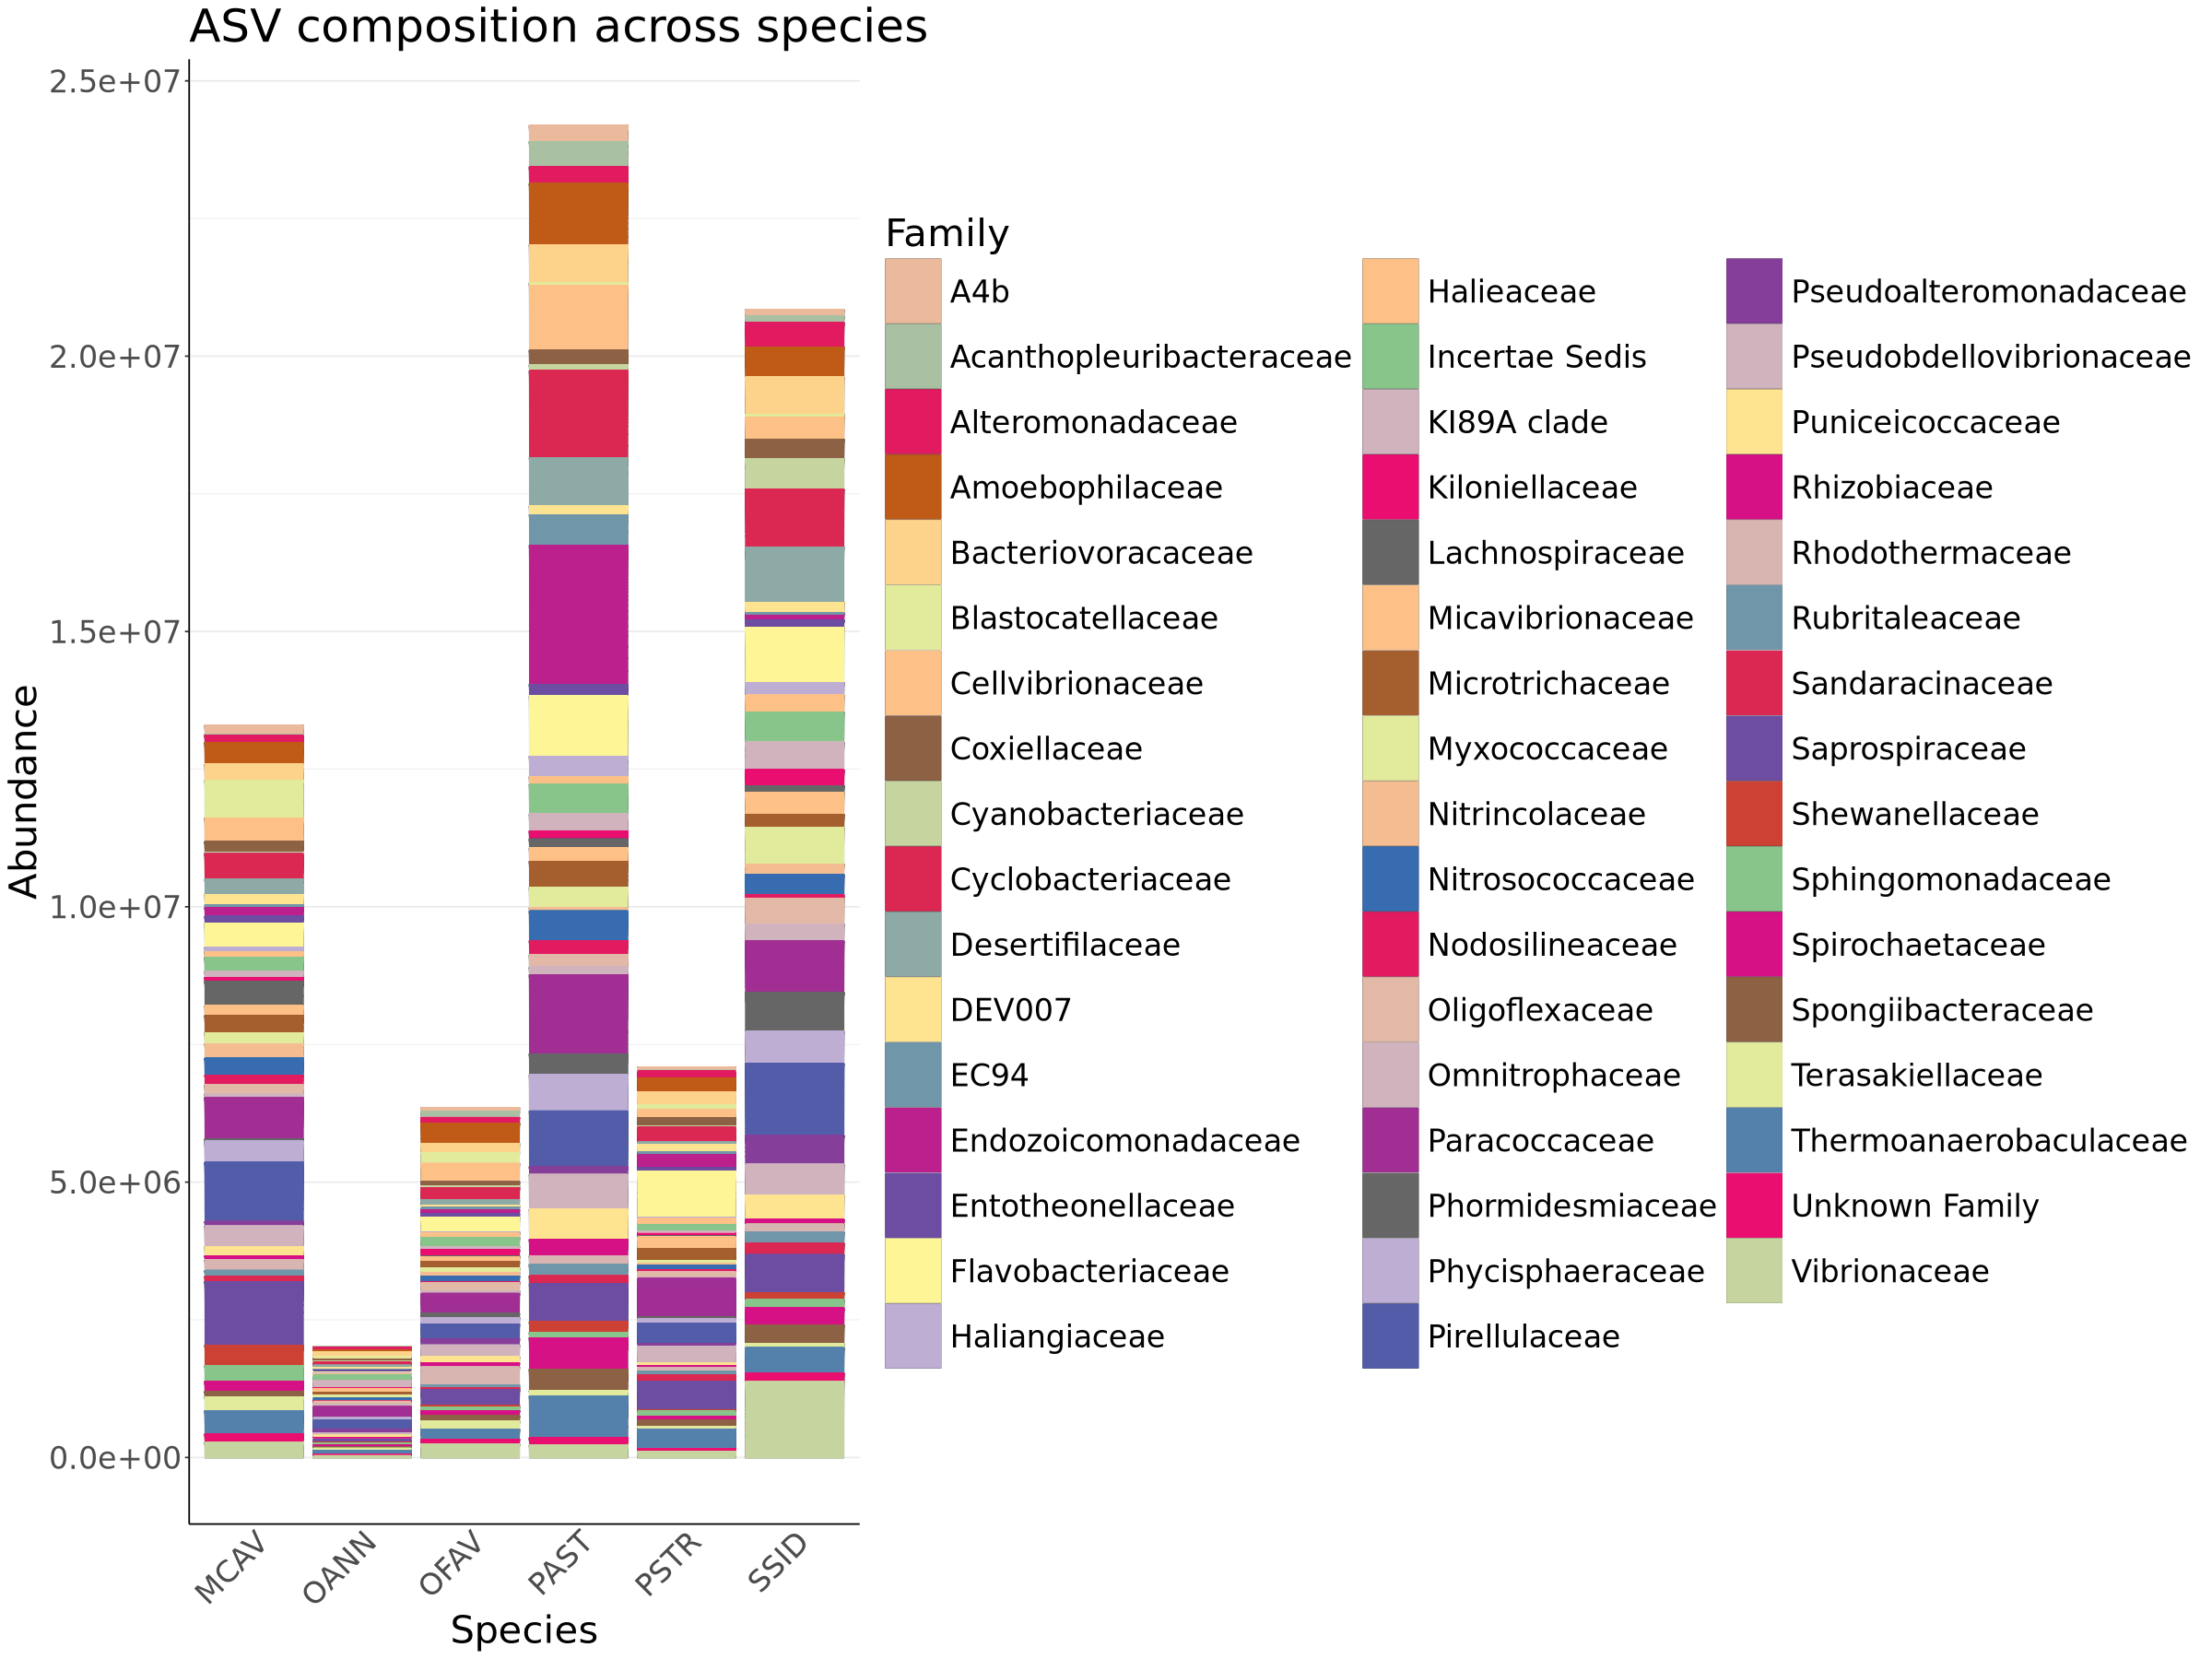

In [206]:
fam <- plot_bar(ps_fam, x="Species", fill = "Family") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  labs(title = "ASV composition across species",
       x = "Species",
       y = "Abundance",
       color = "Family") +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 25),
  legend.text = element_text(size = 20),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
fam